# Libraries

In [431]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error, r2_score, mean_absolute_error

In [432]:
df = pd.read_csv("/content/heart_disease_uci.csv")

In [433]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [434]:
df.shape

(920, 16)

In [435]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [436]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


In [437]:
#df.dropna()

In [438]:
df.duplicated().sum()

np.int64(0)

In [439]:
df.drop("id", axis=1, inplace=True)

In [440]:
df["thal"] = df["thal"].fillna("unknown")
df["slope"] = df["slope"].fillna("unknown")
df["ca"] = df["ca"].fillna(-1)

print(df["thal"].value_counts(dropna=False))
print()
print(df["slope"].value_counts(dropna=False))
print()
print(df["ca"].value_counts(dropna=False).sort_index())


thal
unknown              486
normal               196
reversable defect    192
fixed defect          46
Name: count, dtype: int64

slope
flat           345
unknown        309
upsloping      203
downsloping     63
Name: count, dtype: int64

ca
-1.0    611
 0.0    181
 1.0     67
 2.0     41
 3.0     20
Name: count, dtype: int64


In [441]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print("\n", col)
    print(df[col].value_counts(dropna=False))


 sex
sex
Male      726
Female    194
Name: count, dtype: int64

 dataset
dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64

 cp
cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: count, dtype: int64

 fbs
fbs
False    692
True     138
NaN       90
Name: count, dtype: int64

 restecg
restecg
normal              551
lv hypertrophy      188
st-t abnormality    179
NaN                   2
Name: count, dtype: int64

 exang
exang
False    528
True     337
NaN       55
Name: count, dtype: int64

 slope
slope
flat           345
unknown        309
upsloping      203
downsloping     63
Name: count, dtype: int64

 thal
thal
unknown              486
normal               196
reversable defect    192
fixed defect          46
Name: count, dtype: int64


In [442]:
print("trestbps zeros:", (df["trestbps"] == 0).sum())
print("chol zeros:", (df["chol"] == 0).sum())

trestbps zeros: 1
chol zeros: 172


In [443]:
df["trestbps"] = df["trestbps"].replace(0, np.nan)
df["chol"] = df["chol"].replace(0, np.nan)

In [444]:
num_cols_to_impute = ["trestbps", "chol", "thalch", "oldpeak"]
for col in num_cols_to_impute:
    df[col] = df[col].fillna(df[col].median())

cat_cols_to_impute = ["exang", "fbs", "restecg"]
for col in cat_cols_to_impute:
    df[col] = df[col].fillna(df[col].mode()[0])
df.isnull().sum()


/tmp/ipykernel_454/2699945748.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


,0
age,0
sex,0
dataset,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0


In [445]:
df["num"].value_counts().sort_index()

,count
num,
0,411
1,265
2,109
3,107
4,28


In [446]:
df["target"] = (df["num"] > 0).astype(int)

In [447]:
df.drop("num", axis=1, inplace=True)

**EDA**

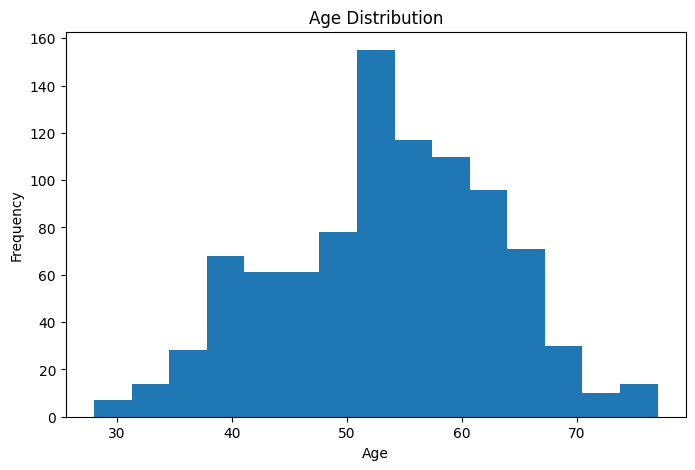

In [448]:
plt.figure(figsize=(8,5))

plt.hist(df["age"], bins=15)

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")

plt.show()

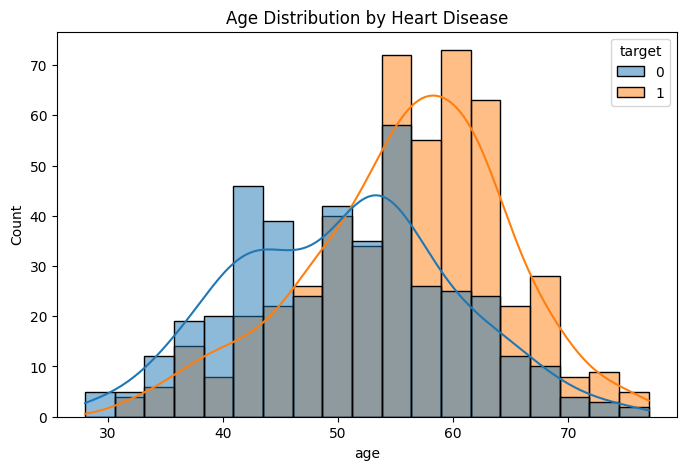

In [449]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="age", hue="target", kde=True)

plt.title("Age Distribution by Heart Disease")
plt.show()

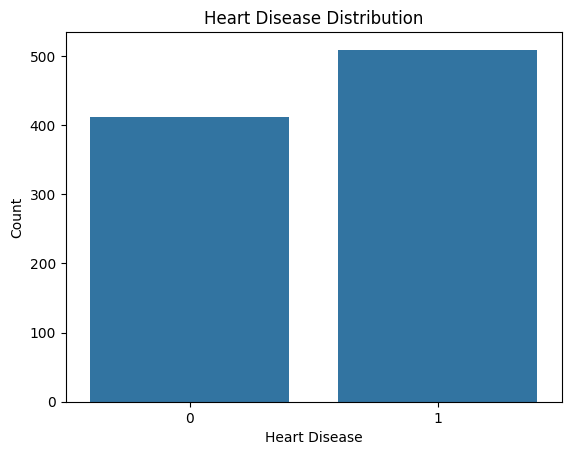

In [450]:
sns.countplot(x="target", data=df)

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()

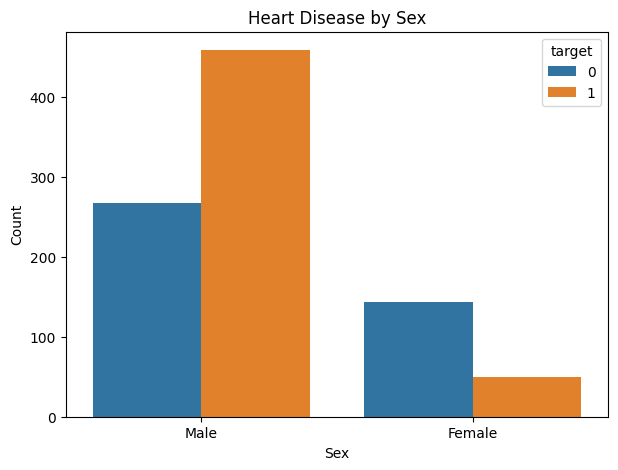

In [451]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="sex", hue="target")

plt.title("Heart Disease by Sex")
plt.xlabel("Sex")
plt.ylabel("Count")

plt.show()

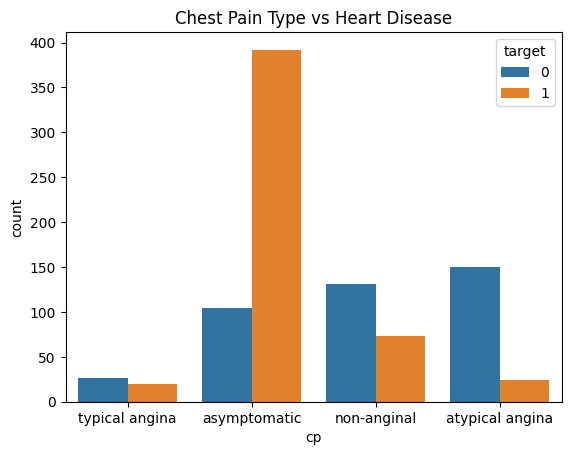

In [452]:
sns.countplot(x="cp", hue="target", data=df)

plt.title("Chest Pain Type vs Heart Disease")
plt.show()

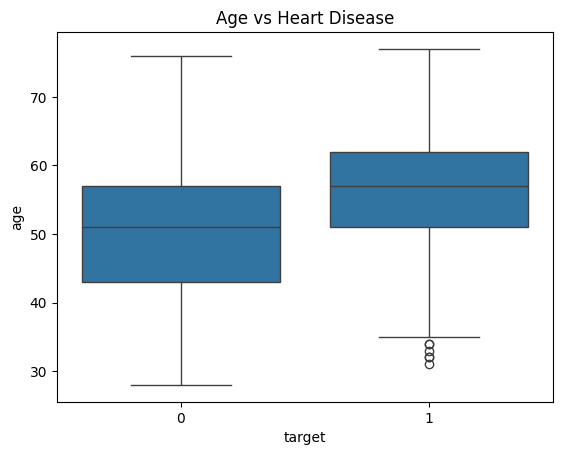

In [453]:
sns.boxplot(x="target", y="age", data=df)

plt.title("Age vs Heart Disease")
plt.show()

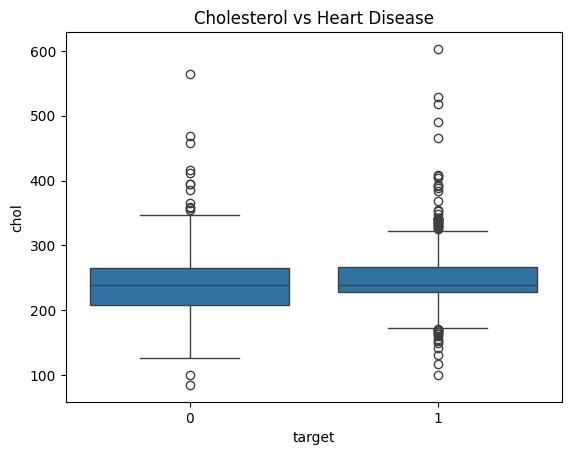

In [454]:
sns.boxplot(x="target", y="chol", data=df)

plt.title("Cholesterol vs Heart Disease")
plt.show()

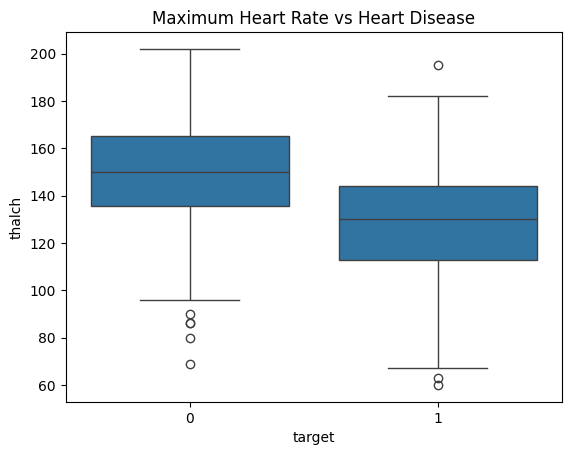

In [455]:
sns.boxplot(x="target", y="thalch", data=df)

plt.title("Maximum Heart Rate vs Heart Disease")
plt.show()

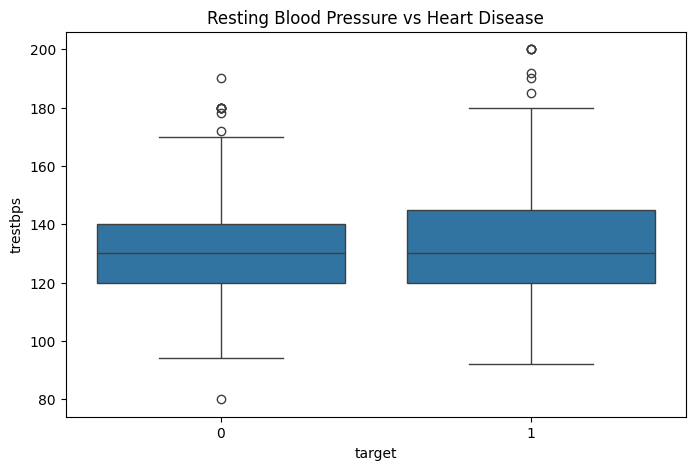

In [456]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="target", y="trestbps")

plt.title("Resting Blood Pressure vs Heart Disease")
plt.show()

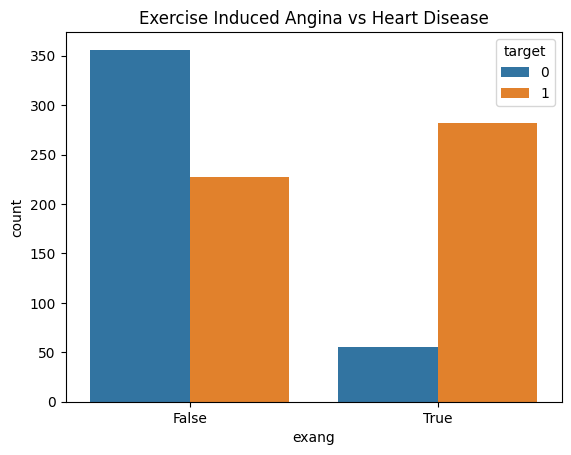

In [457]:
sns.countplot(x="exang", hue="target", data=df)

plt.title("Exercise Induced Angina vs Heart Disease")
plt.show()

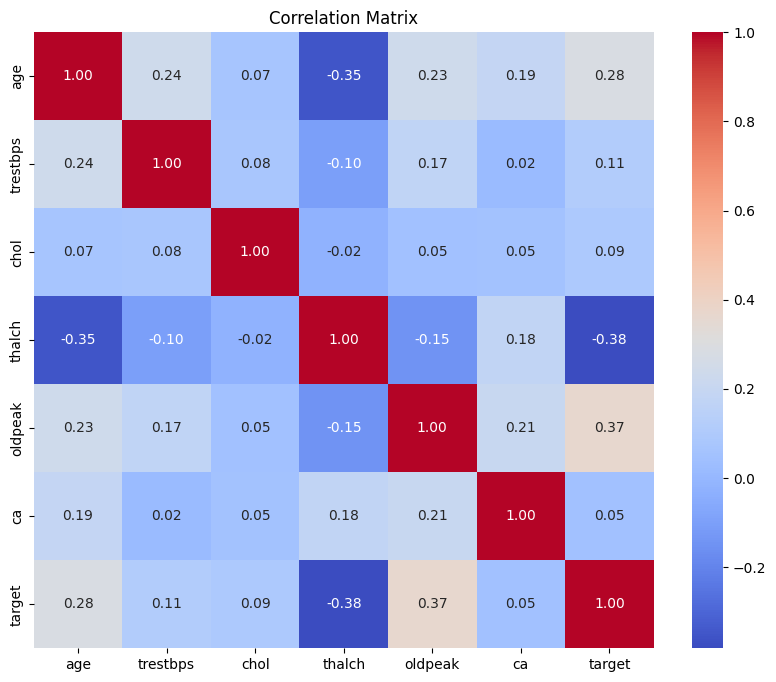

In [458]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

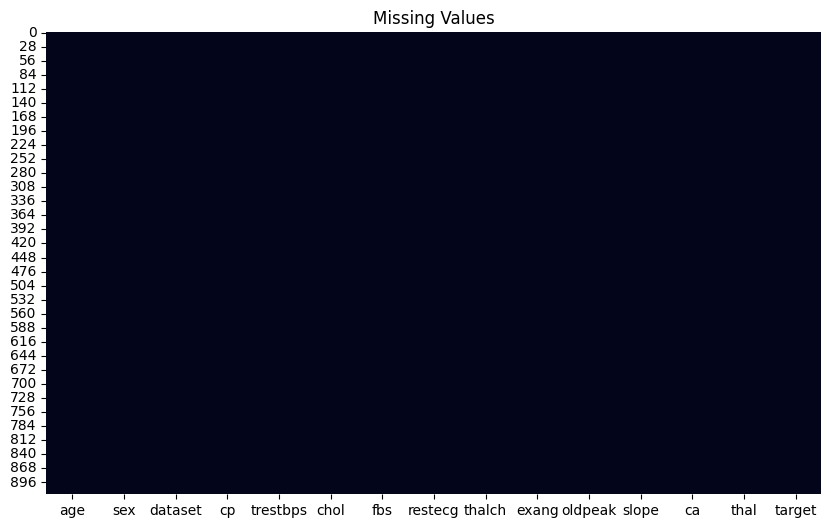

In [459]:
plt.figure(figsize=(10,6))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values")

plt.show()

In [460]:
df["sex"] = df["sex"].map({"Male": 1, "Female": 0})
df["fbs"] = df["fbs"].astype(int)
df["exang"] = df["exang"].astype(int)

nominal_cols = ["cp", "restecg", "slope", "thal", "dataset"]
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

df.head()


,age,sex,trestbps,chol,fbs,thalch,exang,oldpeak,ca,target,...,restecg_st-t abnormality,slope_flat,slope_unknown,slope_upsloping,thal_normal,thal_reversable defect,thal_unknown,dataset_Hungary,dataset_Switzerland,dataset_VA Long Beach
0,63,1,145.0,233.0,1,150.0,0,2.3,0.0,0,...,False,False,False,False,False,False,False,False,False,False
1,67,1,160.0,286.0,0,108.0,1,1.5,3.0,1,...,False,True,False,False,True,False,False,False,False,False
2,67,1,120.0,229.0,0,129.0,1,2.6,2.0,1,...,False,True,False,False,False,True,False,False,False,False
3,37,1,130.0,250.0,0,187.0,0,3.5,0.0,0,...,False,False,False,False,True,False,False,False,False,False
4,41,0,130.0,204.0,0,172.0,0,1.4,0.0,0,...,False,False,False,True,True,False,False,False,False,False


In [461]:
cols_to_scale = ["age", "trestbps", "chol", "thalch", "oldpeak"]

scaler = StandardScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

df[cols_to_scale].describe()


,age,trestbps,chol,thalch,oldpeak
count,9.200000e+02,9.200000e+02,9.200000e+02,9.200000e+02,9.200000e+02
mean,6.178632e-17,-3.552714e-16,-1.660507e-16,-4.016111e-16,-2.316987e-17
std,1.000544e+00,1.000544e+00,1.000544e+00,1.000544e+00,1.000544e+00
min,-2.708286e+00,-2.909426e+00,-3.095664e+00,-3.091427e+00,-3.265577e+00
25%,-6.912073e-01,-6.772850e-01,-5.308023e-01,-7.039908e-01,-8.068863e-01
50%,5.192709e-02,-1.192497e-01,-1.105707e-01,9.182113e-02,-3.340612e-01
75%,6.888994e-01,4.387856e-01,4.207566e-01,7.284707e-01,6.115890e-01
max,2.493654e+00,3.786997e+00,6.912610e+00,2.558838e+00,5.056145e+00


# Modeling

In [462]:
categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
if 'target' in categorical_cols:
    categorical_cols.remove('target')

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

LOGISTIC REGRESSION

In [463]:
X_clf = df_encoded.drop('target', axis=1)
y_clf = df_encoded['target']

In [464]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

In [465]:
scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

In [466]:
model_clf = LogisticRegression()
model_clf.fit(X_train_clf_scaled, y_train_clf)

LogisticRegression()

In [467]:
y_pred_clf = model_clf.predict(X_test_clf_scaled)

In [468]:
print("Accuracy Score:", accuracy_score(y_test_clf, y_pred_clf))
print("Confusion Matrix:", confusion_matrix(y_test_clf, y_pred_clf))
print("Classification Report:", classification_report(y_test_clf, y_pred_clf))

Accuracy Score: 0.8206521739130435
Confusion Matrix: [[60 15]
 [18 91]]
Classification Report:               precision    recall  f1-score   support

           0       0.77      0.80      0.78        75
           1       0.86      0.83      0.85       109

    accuracy                           0.82       184
   macro avg       0.81      0.82      0.82       184
weighted avg       0.82      0.82      0.82       184



In [469]:
y_pred_train_clf = model_clf.predict(X_train_clf_scaled)
y_pred_test_clf = model_clf.predict(X_test_clf_scaled)

train_acc_clf = accuracy_score(y_train_clf, y_pred_train_clf)
test_acc_clf = accuracy_score(y_test_clf, y_pred_test_clf)

print(accuracy_score(y_train_clf , y_pred_train_clf))
print(accuracy_score(y_test_clf , y_pred_test_clf))

0.84375
0.8206521739130435


In [470]:
print(classification_report(y_test_clf, y_pred_test_clf))

              precision    recall  f1-score   support

           0       0.77      0.80      0.78        75
           1       0.86      0.83      0.85       109

    accuracy                           0.82       184
   macro avg       0.81      0.82      0.82       184
weighted avg       0.82      0.82      0.82       184



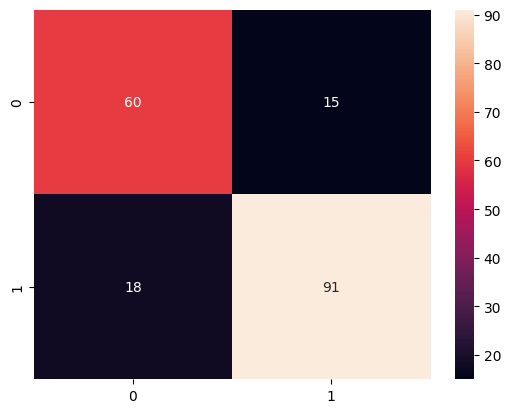

In [471]:
sns.heatmap(confusion_matrix(y_test_clf, y_pred_test_clf), annot=True, fmt='')
plt.show()

LINEAR REGRESSION

In [472]:
X_lin = df_encoded.drop('target', axis=1)
y_lin = df_encoded['target']

In [473]:
X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(X_lin, y_lin, test_size=0.2, random_state=42)

In [474]:
scaler_lin = StandardScaler()
X_train_lin_scaled = scaler_lin.fit_transform(X_train_lin)
X_test_lin_scaled = scaler_lin.transform(X_test_lin)

In [475]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_lin_scaled, y_train_lin)

LinearRegression()

In [476]:
y_pred_lin = lin_reg.predict(X_test_lin_scaled)

In [477]:
mae = mean_absolute_error(y_test_lin, y_pred_lin)
mse = mean_squared_error(y_test_lin, y_pred_lin)
r2 = r2_score(y_test_lin, y_pred_lin)

In [478]:
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", np.sqrt(mse))
print("R2 Score:", r2)

Mean Absolute Error (MAE): 0.2745581573579422
Mean Squared Error (MSE): 0.12351576689479267
Root Mean Squared Error (RMSE): 0.35144809985941405
R2 Score: 0.4884709719889785


In [479]:
y_pred_train_lin = lin_reg.predict(X_train_lin_scaled)
y_pred_test_lin = lin_reg.predict(X_test_lin_scaled)

print("Training R2 Score:", r2_score(y_train_lin, y_pred_train_lin))
print("Testing R2 Score: ", r2_score(y_test_lin, y_pred_test_lin))

print("Training MAE:     ", mean_absolute_error(y_train_lin, y_pred_train_lin))
print("Testing MAE:      ", mean_absolute_error(y_test_lin, y_pred_test_lin))

Training R2 Score: 0.5144524729451361
Testing R2 Score:  0.4884709719889785
Training MAE:      0.2691997258720821
Testing MAE:       0.2745581573579422


KNN

In [480]:
knn_model = KNeighborsClassifier()
knn_model.fit(X_train_clf_scaled, y_train_clf)

y_pred_train = knn_model.predict(X_train_clf_scaled)
y_pred_test = knn_model.predict(X_test_clf_scaled)

train_score_knn = accuracy_score(y_train_clf, y_pred_train)
test_score_knn = accuracy_score(y_test_clf, y_pred_test)

print(f'train accuracy of KNN is {train_score_knn}')
print(f'test accuracy of KNN is {test_score_knn}')

train accuracy of KNN is 0.8573369565217391
test accuracy of KNN is 0.842391304347826


In [481]:
k_range = range(5, 25, 2)
train_acc = []
test_acc = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_clf_scaled, y_train_clf)

    y_pred_train = knn.predict(X_train_clf_scaled)
    y_pred_test = knn.predict(X_test_clf_scaled)

    train_acc.append(accuracy_score(y_train_clf, y_pred_train))
    test_acc.append(accuracy_score(y_test_clf, y_pred_test))
print(train_acc)
print(test_acc)

[0.8573369565217391, 0.8383152173913043, 0.8478260869565217, 0.8410326086956522, 0.8410326086956522, 0.8301630434782609, 0.8315217391304348, 0.8288043478260869, 0.8233695652173914, 0.8288043478260869]
[0.842391304347826, 0.842391304347826, 0.8695652173913043, 0.8641304347826086, 0.8532608695652174, 0.8478260869565217, 0.8369565217391305, 0.8695652173913043, 0.8641304347826086, 0.8586956521739131]


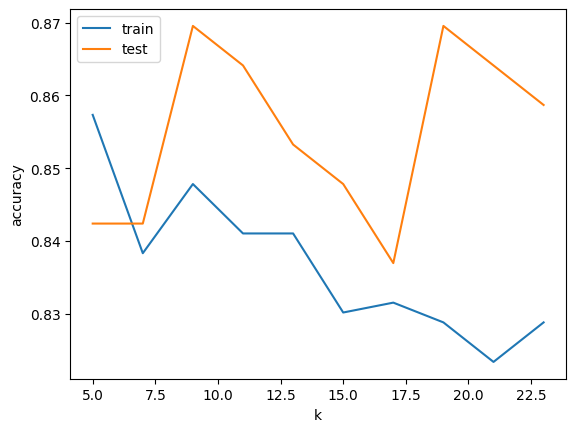

In [482]:
plt.plot(k_range, train_acc, label='train')
plt.plot(k_range, test_acc, label='test')
plt.xlabel('k')
plt.ylabel('accuracy')
plt.legend()
plt.show()

Naive Bayes

In [483]:
nb_model = GaussianNB()
nb_model.fit(X_train_clf_scaled, y_train_clf)

y_pred_train = nb_model.predict(X_train_clf_scaled)
y_pred_test = nb_model.predict(X_test_clf_scaled)

train_score_nb = accuracy_score(y_train_clf, y_pred_train)
test_score_nb = accuracy_score(y_test_clf, y_pred_test)

print(f'train accuracy of Naive Bayes is {train_score_nb}')
print(f'test accuracy of Naive Bayes is {test_score_nb}')

train accuracy of Naive Bayes is 0.8328804347826086
test accuracy of Naive Bayes is 0.8260869565217391


DECISION TREE

In [484]:
dt_model = DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, random_state=42)
dt_model.fit(X_train_clf_scaled, y_train_clf)

y_pred_train_dt = dt_model.predict(X_train_clf_scaled)
y_pred_test_dt = dt_model.predict(X_test_clf_scaled)

train_score_dt = accuracy_score(y_train_clf, y_pred_train_dt)
test_score_dt = accuracy_score(y_test_clf, y_pred_test_dt)

print(f'train accuracy of Decision Tree is {train_score_dt}')
print(f'test accuracy of Decision Tree is {test_score_dt}')

train accuracy of Decision Tree is 0.8165760869565217
test accuracy of Decision Tree is 0.7880434782608695


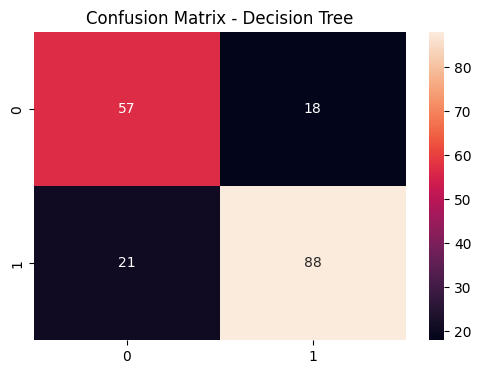

In [485]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test_clf, y_pred_test_dt), annot=True, fmt='')
plt.title("Confusion Matrix - Decision Tree")
plt.show()

RANDOM FOREST

In [486]:
rf_model = RandomForestClassifier(max_depth=6, min_samples_leaf=5, n_estimators=200, random_state=42)
rf_model.fit(X_train_clf_scaled, y_train_clf)

y_pred_train_rf = rf_model.predict(X_train_clf_scaled)
y_pred_test_rf = rf_model.predict(X_test_clf_scaled)

train_score_rf = accuracy_score(y_train_clf, y_pred_train_rf)
test_score_rf = accuracy_score(y_test_clf, y_pred_test_rf)

print(f'train accuracy of Random Forest is {train_score_rf}')
print(f'test accuracy of Random Forest is {test_score_rf}')
print(f'Classification Report (Random Forest): {classification_report(y_test_clf, y_pred_test_rf)}')

train accuracy of Random Forest is 0.8586956521739131
test accuracy of Random Forest is 0.8478260869565217
Classification Report (Random Forest):               precision    recall  f1-score   support

           0       0.81      0.81      0.81        75
           1       0.87      0.87      0.87       109

    accuracy                           0.85       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.85      0.85      0.85       184



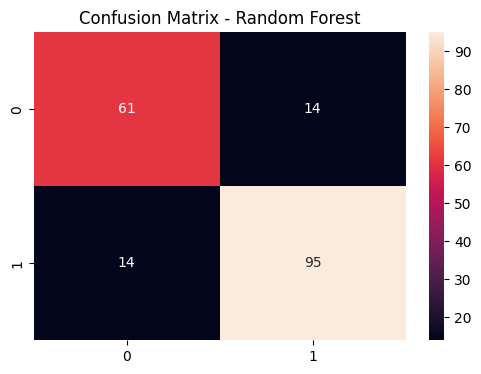

In [487]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test_clf, y_pred_test_rf), annot=True, fmt='')
plt.title("Confusion Matrix - Random Forest")
plt.show()

ADABOOST

In [488]:
ada_model = AdaBoostClassifier(random_state=42)
ada_model.fit(X_train_clf_scaled, y_train_clf)

y_pred_train_ada = ada_model.predict(X_train_clf_scaled)
y_pred_test_ada = ada_model.predict(X_test_clf_scaled)

train_score_ada = accuracy_score(y_train_clf, y_pred_train_ada)
test_score_ada = accuracy_score(y_test_clf, y_pred_test_ada)

print(f'train accuracy of AdaBoost is {train_score_ada}')
print(f'test accuracy of AdaBoost is {test_score_ada}')
print("\nClassification Report (AdaBoost):")
print(classification_report(y_test_clf, y_pred_test_ada))

train accuracy of AdaBoost is 0.8355978260869565
test accuracy of AdaBoost is 0.8260869565217391

Classification Report (AdaBoost):
              precision    recall  f1-score   support

           0       0.77      0.81      0.79        75
           1       0.87      0.83      0.85       109

    accuracy                           0.83       184
   macro avg       0.82      0.82      0.82       184
weighted avg       0.83      0.83      0.83       184



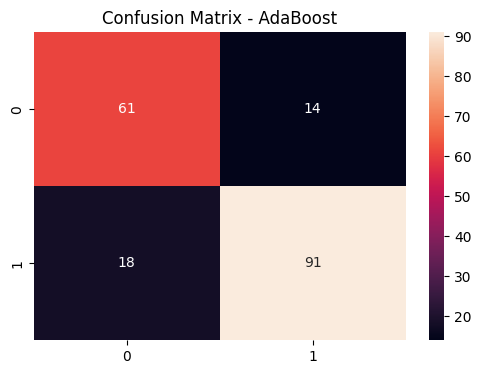

In [489]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test_clf, y_pred_test_ada), annot=True, fmt='')
plt.title("Confusion Matrix - AdaBoost")
plt.show()

Best Model

In [490]:
models = {
    'Logistic Regression': LogisticRegression(),
    'Linear Regression': LinearRegression(),
    'Naive Bayes': GaussianNB(),
    'KNN': KNeighborsClassifier(n_neighbors=10),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, random_state=42),
    'Random Forest': RandomForestClassifier(max_depth=6, min_samples_leaf=5, n_estimators=200, random_state=42),
    'Adaboost': AdaBoostClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train_clf_scaled, y_train_clf)

    y_pred_train = model.predict(X_train_clf_scaled)
    y_pred_test = model.predict(X_test_clf_scaled)

    if name == 'Linear Regression':
        y_pred_train = np.round(y_pred_train).clip(0, 1)
        y_pred_test = np.round(y_pred_test).clip(0, 1)

    print(f'{name}  train accuracy is {accuracy_score(y_train_clf, y_pred_train)}')
    print(f'{name}  test accuracy is {accuracy_score(y_test_clf, y_pred_test)}')
    print('-'*50)

Logistic Regression  train accuracy is 0.84375
Logistic Regression  test accuracy is 0.8206521739130435
--------------------------------------------------
Linear Regression  train accuracy is 0.84375
Linear Regression  test accuracy is 0.8315217391304348
--------------------------------------------------
Naive Bayes  train accuracy is 0.8328804347826086
Naive Bayes  test accuracy is 0.8260869565217391
--------------------------------------------------
KNN  train accuracy is 0.84375
KNN  test accuracy is 0.8641304347826086
--------------------------------------------------
Decision Tree  train accuracy is 0.8165760869565217
Decision Tree  test accuracy is 0.7880434782608695
--------------------------------------------------
Random Forest  train accuracy is 0.8586956521739131
Random Forest  test accuracy is 0.8478260869565217
--------------------------------------------------
Adaboost  train accuracy is 0.8355978260869565
Adaboost  test accuracy is 0.8260869565217391
--------------------